# Bài 4: Lọc tín hiệu cơ bản (Low-pass / High-pass)

**Mục tiêu:**
- Áp dụng bộ lọc thông thấp (low-pass) và thông cao (high-pass) đơn giản.
- So sánh waveform và phổ trước/sau lọc.

**Phương pháp minh họa:**
- Thiết kế FIR đơn giản bằng cửa sổ (windowed-sinc) hoặc lọc trong miền tần số (FFT).

In [ ]:
#@title Cài đặt (nếu cần)
# !pip install scipy matplotlib numpy


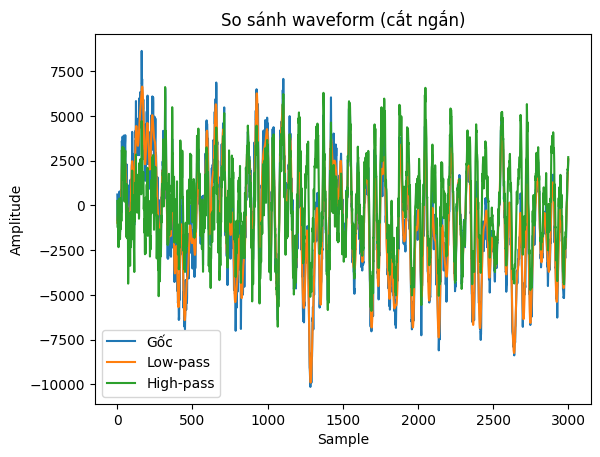

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from numpy.fft import rfft, rfftfreq, irfft

filename = "sample-6s.wav"
rate, data = wavfile.read(filename)
if data.ndim == 2:
    data = data[:,0]
data = data.astype(np.float32)

# Hàm lọc thông thấp bằng FFT: zero-out tần số > cutoff
def lowpass_fft(x, fs, cutoff_hz):
    N = len(x)
    X = rfft(x)
    freqs = rfftfreq(N, 1.0/fs)
    mask = freqs <= cutoff_hz
    X_filtered = X * mask
    return irfft(X_filtered, n=N)

# Hàm lọc thông cao: zero-out tần số < cutoff
def highpass_fft(x, fs, cutoff_hz):
    N = len(x)
    X = rfft(x)
    freqs = rfftfreq(N, 1.0/fs)
    mask = freqs >= cutoff_hz
    X_filtered = X * mask
    return irfft(X_filtered, n=N)

cutoff_lp = 2000.0  # Hz
cutoff_hp = 200.0   # Hz

y_lp = lowpass_fft(data, rate, cutoff_lp)
y_hp = highpass_fft(data, rate, cutoff_hp)

# Waveform so sánh
N_show = min(len(data), 3000)
plt.figure()
plt.plot(np.arange(N_show), data[:N_show], label="Gốc")
plt.plot(np.arange(N_show), y_lp[:N_show], label="Low-pass")
plt.plot(np.arange(N_show), y_hp[:N_show], label="High-pass")
plt.title("So sánh waveform (cắt ngắn)")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.legend()
plt.show()

### So sánh phổ biên độ

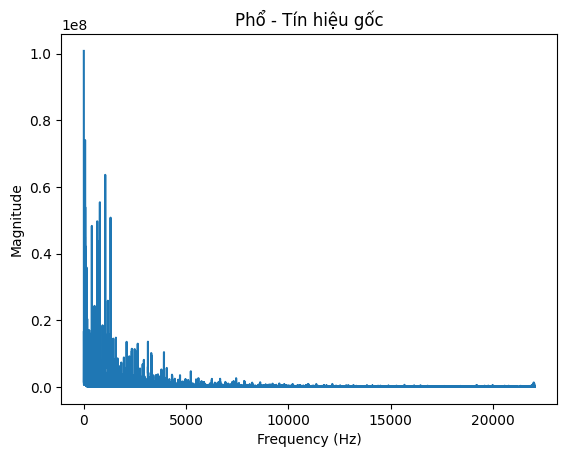

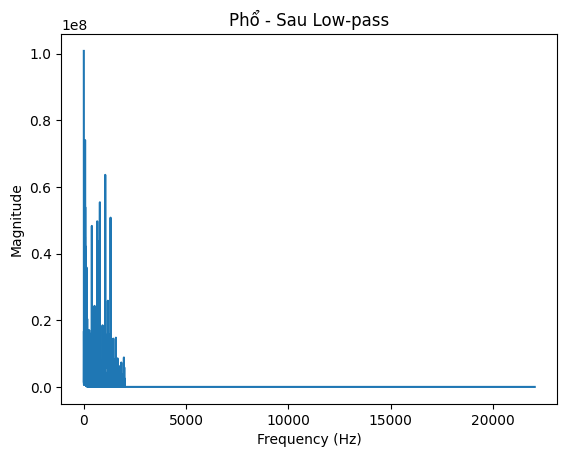

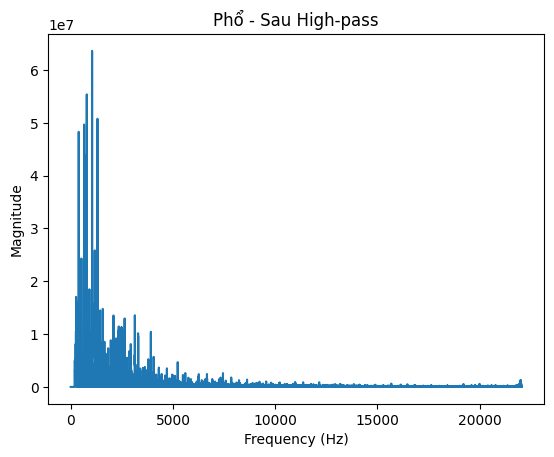

In [3]:
def plot_spectrum(x, fs, title):
    N = len(x)
    X = np.fft.rfft(x)
    f = np.fft.rfftfreq(N, 1.0/fs)
    import matplotlib.pyplot as plt
    plt.figure()
    plt.plot(f, np.abs(X))
    plt.title(title)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude")
    plt.show()

plot_spectrum(data, rate, "Phổ - Tín hiệu gốc")
plot_spectrum(y_lp, rate, "Phổ - Sau Low-pass")
plot_spectrum(y_hp, rate, "Phổ - Sau High-pass")

### Ghi file sau lọc

In [4]:
from scipy.io.wavfile import write
# Chuẩn hóa về int16 khi ghi
def to_int16(x):
    x = x / max(1e-9, np.max(np.abs(x)))
    return (x * 32767).astype(np.int16)

write("example_lowpass.wav", rate, to_int16(y_lp))
write("example_highpass.wav", rate, to_int16(y_hp))
print("Đã ghi example_lowpass.wav & example_highpass.wav")

Đã ghi example_lowpass.wav & example_highpass.wav
